In [1]:
# making somewhat cleaned-up versions of figures for Figure 2 in the main text + related Supplementary Figures
# note that the figures produced by this code were subsequently edited in Adobe Illustrator
# (arranged into main and supplementary figures & annotated; nothing beyond that was changed)

In [2]:
import os
import re
import importlib
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib import cm
import matplotlib.font_manager

import utils
importlib.reload(utils); utils.versions()

re=2.2.1
pd=2.2.2
np=1.26.4
sp=1.11.4
sns=0.13.2
matplotlib=3.9.2


In [3]:
# pre-processed data:
metadata = utils.metadata 
read_counts_by_cell_line = utils.read_counts_by_cell_line
cell_counts_by_cell_line = utils.cell_counts_by_cell_line

clIDs = utils.clIDs; clIDs_no_spikein = utils.clIDs_no_spikein; clIDs_rep = utils.clIDs_rep
clID__label = utils.clID__label; clID_replicates__linestyle = utils.clID_replicates__linestyle
clID__color_1 = utils.clID__color_in_vivo_exp1 # based on burden from series one
clID__color_2 = utils.clID__color_in_vivo_exp2 # based on burden from series two

path_to_reads = utils.path_to_reads 
path_to_save_figs = utils.path_to_save_figs

# loading bootstrapped statistics (this might take a while):
# see bootstrapping.ipynb for bootstrapping details
path_to_bootstraps = '../data/bootstraps/'
files = [f for f in os.listdir(path_to_bootstraps) if f.endswith('.npy')]
what__relative_burden_bootstraps = {}
what__n_tumors_bootstraps = {}
for file in files:
    full_path = os.path.join(path_to_bootstraps, file)
    key = file.replace('.npy', '')
    if file.startswith('burden_bootstrap__'):
        what__relative_burden_bootstraps[key] = dict(np.load(full_path, allow_pickle=True))
    elif file.startswith('n_tumors_bootstrap__'):
        what__n_tumors_bootstraps[key] = dict(np.load(full_path, allow_pickle=True))

### In vitro expansion

In [4]:
in_vitro_samples = metadata[
    (metadata['experiment'] == 'in vitro') |
    ((metadata['time point, d'] == 0) & (metadata['experiment'] == '1'))
].groupby('time point, d')\
 .apply(lambda df: df.index.tolist(), include_groups=False)

clIDs_ordered_in_vitro = ['AGGT', 'AGCA', 'CTTC', 'AGTC', 'ATCG', 'GAAG', 'CACT', 'ACCT',
                          'CCTT', 'CATG', 'GGAA', 'ACAC', 'GTTG', 'AGAG', 'TTGG', 'TCCA',
                          'CTGT', 'TTCC', 'CAGA', 'GCAT', 'CGTA', 'GGTT', 'ACGA', 'AAGG',
                          'GTAC', 'CGAT', 'GCTA', 'CAAC', 'TGAC', 'ATGC', 'ACTG', 'GTGA',
                          'CCAA'] # clIDs sorted by avg expansion in vitro

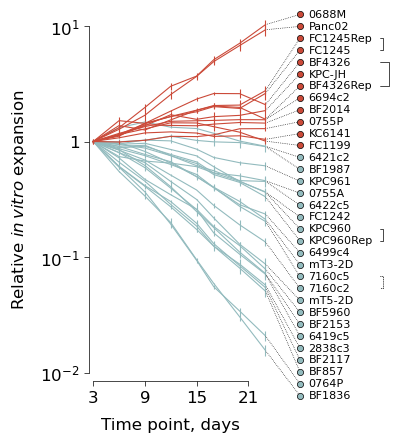

In [5]:
name = 'in_vitro_time_series_w_labels'
si = 'main'

plt.figure(figsize=(2, 4.5));
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().spines['bottom'].set_position(('axes', -0.025))
plt.gca().spines['left'].set_position(('axes', -0.025))
plt.gca().tick_params(width=0.5)
for spine in ['bottom', 'left']:
    plt.gca().spines[spine].set_linewidth(0.5)

ls = np.logspace(1.1, -2.2, len(clIDs_ordered_in_vitro))
for count, clID in enumerate(clIDs_ordered_in_vitro):  
    
    xs = []
    ys = []
    errs = []
    
    # normalizing by the avg fraction at t = 3 days (or the first post-growth time point)
    t = 3
    norm = np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in in_vitro_samples[t]])
    
    for time_point, sample_ids in in_vitro_samples.items():
        if time_point < 3:
            continue
        xs.append(time_point)
        
        fracs = [read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in sample_ids]
        ys.append(np.mean(fracs / norm))
        errs.append(np.std(fracs / norm))
    
    if ys[-1] >= 1:
        c = '#cb4a39'
        z = 1
    else:
        c = '#93bbbe'
        z = -1
    plt.errorbar(xs, ys, errs, color=c, linewidth=0.8, alpha=1, zorder=z, clip_on=False)
   
    plt.text(28, ls[count], clID__label[clID], size=8, va='center')
    plt.plot([xs[-1], 27], [ys[-1], ls[count]], linewidth=0.5, linestyle=':', color='black', clip_on=False, zorder=-1)
    
    plt.scatter(27, ls[count], color=c, edgecolor='black', linewidth=0.5, s=20, clip_on=False)
    
# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = 36
    y = sorted([ls[clIDs_ordered_in_vitro.index(key[0])], ls[clIDs_ordered_in_vitro.index(key[1])]])
    plt.annotate('', xy=(x, y[0]), xycoords='data', xytext=(x, y[1]), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.5'),
                annotation_clip=False);
   
plt.yscale('log'); plt.minorticks_off();
plt.xlim(t, 21)
plt.ylim(1e-2, 1e1)
plt.xticks([3, 9, 15, 21], size=12)
plt.yticks([1e-2, 1e-1, 1e0, 1e1], ['$10^{-2}$', '$10^{-1}$', '1', '$10^1$'], size=12)

plt.xlabel('Time point, days', fontsize=12, labelpad=8);
plt.ylabel('Relative ' + r'$\mathit{in\,vitro}$' + ' expansion', fontsize=12, labelpad=8);

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

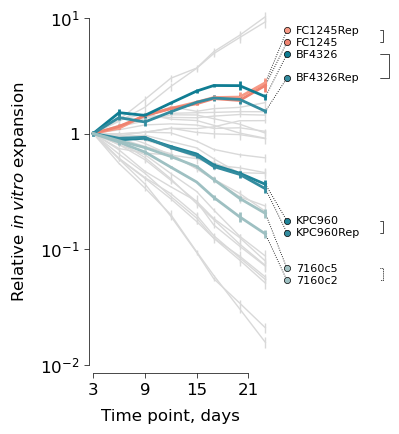

In [6]:
name = 'in_vitro_time_series_w_labels_reps'
si = 'si'

plt.figure(figsize=(2, 4.5));
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().spines['bottom'].set_position(('axes', -0.025))
plt.gca().spines['left'].set_position(('axes', -0.025))
plt.gca().tick_params(width=0.5)
for spine in ['bottom', 'left']:
    plt.gca().spines[spine].set_linewidth(0.5)

ls = np.logspace(1.1, -2.2, len(clIDs_ordered_in_vitro))
for count, clID in enumerate(clIDs_ordered_in_vitro): 
    if clID in np.array(clIDs_rep).flatten():
        color = clID__color_1[clID]
        z=1
        a=4
    else:
        color = '#d9d9d9'
        z=-1
        a=2
    
    xs = []
    ys = []
    errs = []
    
    # normalizing by the avg fraction at t = 3 days
    t = 3
    norm = np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in in_vitro_samples[t]])
    
    for time_point, sample_ids in in_vitro_samples.items():
        if time_point < 3:
            continue
        xs.append(time_point)
        
        fracs = [read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in sample_ids]
        ys.append(np.mean(fracs / norm))
        errs.append(np.std(fracs / norm))
            
    plt.errorbar(xs, ys, errs, color=color, zorder=z, linewidth=a*0.5, alpha=1, clip_on=False)

    if clID in np.array(clIDs_rep).flatten():
        plt.text(26.5, ls[count], clID__label[clID], size=8, va='center')
        plt.plot([xs[-1], 25.5], [ys[-1], ls[count]], linewidth=1.25*0.5, linestyle=':', color='black', clip_on=False, zorder=-1)
        plt.scatter(25.5, ls[count], color=color, edgecolor='black', linewidth=0.5, s=20, clip_on=False)
    
# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = 36
    y = sorted([ls[clIDs_ordered_in_vitro.index(key[0])], ls[clIDs_ordered_in_vitro.index(key[1])]])
    plt.annotate('', xy=(x, y[0]), xycoords='data', xytext=(x, y[1]), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.5'),
                annotation_clip=False);
   
plt.yscale('log'); plt.minorticks_off();
plt.xlim(t, 21)
plt.ylim(1e-2, 1e1)
plt.xticks([3, 9, 15, 21], size=12)
plt.yticks([1e-2, 1e-1, 1e0, 1e1], ['$10^{-2}$', '$10^{-1}$', '1', '$10^1$'], size=12)

plt.xlabel('Time point, days', fontsize=12, labelpad=8);
plt.ylabel('Relative ' + r'$\mathit{in\,vitro}$' + ' expansion', fontsize=12, labelpad=8);

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

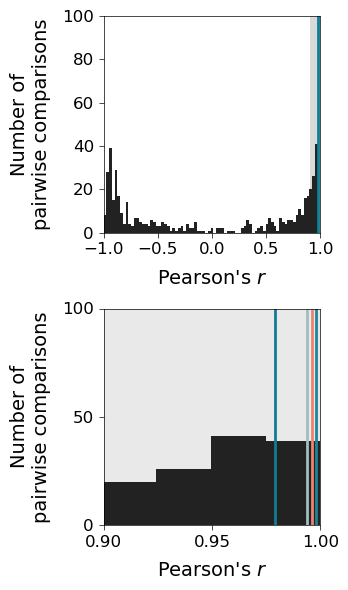

In [7]:
name = 'in_vitro_time_series_pairwise_pearsons_r'
si = 'si'

plt.figure(figsize=(6, 6))
ax_main = plt.subplot(2, 1, 1)  # main histogram
ax_inset = plt.subplot(2, 1, 2)  # previously inset, now a full subplot
ax_main.set_box_aspect(1); ax_inset.set_box_aspect(1)
ax_main.tick_params(width=0.5); ax_inset.tick_params(width=0.5)
for spine in ['top', 'right', 'bottom', 'left']:
    ax_main.spines[spine].set_linewidth(0.5); ax_inset.spines[spine].set_linewidth(0.5)

# looking at correlations between pairs of frequency trajectories
r2 = {}
for (x, y) in itertools.combinations(clIDs_ordered_in_vitro, 2):
        
    xs = []
    ys = []
    
    # normalizing by the avg fraction at t = 3 days
    t = 3
    norm_1 = np.mean([read_counts_by_cell_line[sample_id][x] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in in_vitro_samples[t]])
    norm_2 = np.mean([read_counts_by_cell_line[sample_id][y] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in in_vitro_samples[t]])

    for time_point, sample_ids in in_vitro_samples.items():
        
        fracs_1 = [read_counts_by_cell_line[sample_id][x] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in sample_ids]
        xs.append(np.mean(fracs_1 / norm_1))
        
        fracs_2 = [read_counts_by_cell_line[sample_id][y] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in sample_ids]
        ys.append(np.mean(fracs_2 / norm_2))
    
    r2[tuple(sorted([x, y]))] = stats.pearsonr(xs, ys)  

# plot main histogram
ax_main.hist([x[0] for x in r2.values()], bins=np.linspace(-1, 1, 80), color='#222222')
ax_main.axvspan(0.9, 1, color='#d9d9d9', linewidth=0, zorder=-1)

for rep in clIDs_rep:
    ax_main.axvline(r2[tuple(sorted(rep))][0], color=clID__color_1[rep[0]], linewidth=2)

ax_main.set_xlim(-1, 1)
ax_main.set_ylim(0, 100)
ax_main.tick_params(axis='both', labelsize=12)  
ax_main.set_xlabel("Pearson's $r$", fontsize=14, labelpad=8)
ax_main.set_ylabel('Number of\npairwise comparisons', fontsize=14, labelpad=8)

# inset histogram (now a full subplot in the second row)
ax_inset.hist([x[0] for x in r2.values()], bins=np.linspace(-1, 1, 80), color='#222222')
ax_inset.axvspan(0.9, 1, color='#e9e9e9', linewidth=0, zorder=-1)

for count, rep in enumerate(clIDs_rep):
    ax_inset.axvline(r2[tuple(sorted(rep))][0], color=clID__color_1[rep[0]], linewidth=2)

ax_inset.set_xlim([0.9, 1])
ax_inset.set_ylim([0, 100])
ax_inset.set_xticks([0.9, 0.95, 1])
ax_inset.set_yticks([0, 50, 100])
ax_inset.tick_params(axis='both', labelsize=12)
ax_inset.set_xlabel("Pearson's $r$", fontsize=14, labelpad=8)
ax_inset.set_ylabel('Number of\npairwise comparisons', fontsize=14, labelpad=8)

plt.tight_layout()  
plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

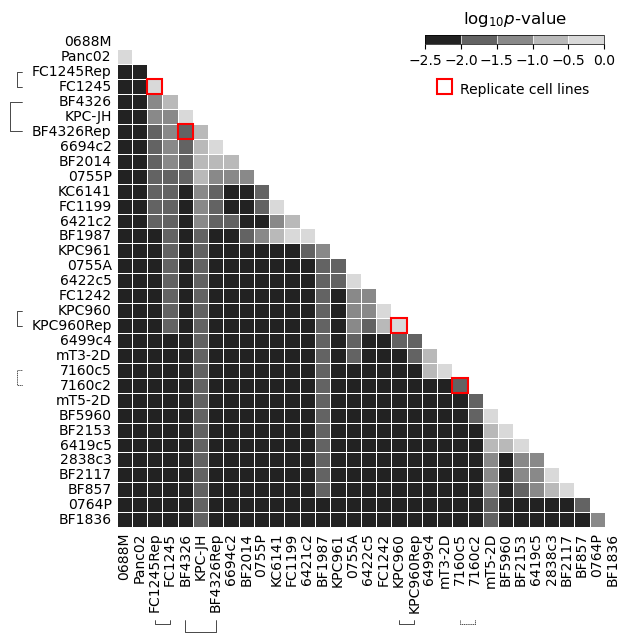

In [8]:
name = 'in_vitro_t=23d_p-vals_w_reps'
si = 'si'

# calculating p-values
cmap = matplotlib.colors.ListedColormap(['#222222', '#636363', '#898989', '#b9b9b9', '#d9d9d9'])  
bounds = [-2.5, -2, -1.5, -1, -0.5, 0]  
norm = matplotlib.colors.BoundaryNorm(bounds, cmap.N)

in_vitro_pvals = {}
for i, j in itertools.combinations(clIDs_ordered_in_vitro, 2):
     
    # normalizing by the fraction at t = 3 days 
    # (not averaging across replicates here, which is different from before)
    t = 3
    norms_i = dict([(count, read_counts_by_cell_line[sample_id][i] / sum(read_counts_by_cell_line[sample_id][1:])) for count, sample_id in enumerate(in_vitro_samples[t])])
    norms_j = dict([(count, read_counts_by_cell_line[sample_id][j] / sum(read_counts_by_cell_line[sample_id][1:])) for count, sample_id in enumerate(in_vitro_samples[t])])

    t = 23 # last time point
    _, p_val = sp.stats.ttest_ind([read_counts_by_cell_line[sample_id][i] / sum(read_counts_by_cell_line[sample_id][1:]) / norms_i[count] for count, sample_id in enumerate(in_vitro_samples[t])], 
                                  [read_counts_by_cell_line[sample_id][j] / sum(read_counts_by_cell_line[sample_id][1:]) / norms_j[count] for count, sample_id in enumerate(in_vitro_samples[t])],
                                  equal_var=False)
    
    in_vitro_pvals[(i, j)] = p_val
    

pval_matrix = np.full((len(clIDs_ordered_in_vitro), len(clIDs_ordered_in_vitro)), np.nan)  # starting with an empty matrix

clID_to_index = {clID: idx for idx, clID in enumerate(clIDs_ordered_in_vitro)}
for (i, j), p_val in in_vitro_pvals.items():
    idx_i, idx_j = clID_to_index[i], clID_to_index[j]
    pval_matrix[idx_i, idx_j] = np.log10(p_val)
    pval_matrix[idx_j, idx_i] = np.log10(p_val)

mask = np.triu(np.ones_like(pval_matrix, dtype=bool))  # mask upper triangle

plt.figure(figsize=(6.5, 8))
ax = sns.heatmap(pval_matrix, cmap=cmap, norm=norm, vmin=-2.5, vmax=0, 
                 xticklabels=[clID__label[x] for x in clIDs_ordered_in_vitro], 
                 yticklabels=[clID__label[x] for x in clIDs_ordered_in_vitro],
                 mask=mask, linewidths=0.5, cbar_kws = dict(use_gridspec=False,location='top')) 
    
# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    y = sorted([clIDs_ordered_in_vitro.index(key[0]) + 0.5, clIDs_ordered_in_vitro.index(key[1]) + 0.5])
    plt.annotate('', xy=(-6, y[0]), xycoords='data', xytext=(-6, y[1]), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.5'),
                annotation_clip=False);

    plt.annotate('', xy=(y[0], 39), xycoords='data', xytext=(y[1], 39), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.5'),
                annotation_clip=False, rotation=90);

cells_to_frame = [(3, 2), (6, 4), (19, 18), (23, 22)] 
for i, j in cells_to_frame:
    rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', linewidth=1.5)
    ax.add_patch(rect)
        
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([-2.5, -2, -1.5, -1, -0.5, 0]) 
colorbar.ax.xaxis.set_ticks_position('bottom') 
ax.tick_params(axis='both', which='both', length=0) 

pos = colorbar.ax.get_position()  
colorbar.ax.set_position([pos.x0 + 0.475, pos.y0 - 0.05, pos.width - 0.5, pos.height]) 

for b in [-0.5, -1, -1.5, -2]:
    colorbar.ax.axvline(b, color='white', linewidth=0.5)
colorbar.ax.set_ylabel('') 
colorbar.ax.set_title('log$_{10}p$-value', fontsize=12, pad=8) 

colorbar.outline.set_visible(True)  
colorbar.outline.set_edgecolor('black')  
colorbar.outline.set_linewidth(0.5)  

rect = plt.Rectangle((21, 3), 1, 1, fill=False, edgecolor='red', linewidth=1.5)
ax.add_patch(rect)
ax.text(22.5, 3.95, 'Replicate cell lines')

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

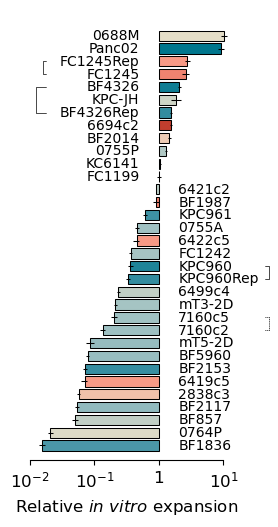

In [9]:
name = 'relative_in_vitro_expansion'
si = 'si'

fig, ax = plt.subplots(figsize=(2.5, 6))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_position(('axes', 0.025))
ax_main.spines['bottom'].set_linewidth(0.5)

clID__in_vitro_exp = {}
clID__in_vitro_exp_err = {}
for clID in clIDs_ordered_in_vitro:
     
    t = 3 # normalizing by the fraction at t = 3 days 
    norm = np.mean([read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) for sample_id in in_vitro_samples[t]])

    t = 23 # last time point
    y = [read_counts_by_cell_line[sample_id][clID] / sum(read_counts_by_cell_line[sample_id][1:]) / norm for sample_id in in_vitro_samples[t]]
    
    clID__in_vitro_exp[clID] = np.mean(y)
    clID__in_vitro_exp_err[clID] = [np.std(y), np.std(y)]

clIDs_sorted_r = clIDs_ordered_in_vitro[::-1]
widths, lefts, xs, errs, cs = [], [], [], [[], []], []

c = 0
for i in clIDs_sorted_r:
    cs.append(clID__color_1[i])
    xs.append(max(1e-3, clID__in_vitro_exp[i]))
    errs[0].append(min(clID__in_vitro_exp_err[i][0], xs[-1] - 1e-3))
    errs[1].append(clID__in_vitro_exp_err[i][1])
        
    if clID__in_vitro_exp[i] > 1:
        lefts.append(1)
        widths.append(clID__in_vitro_exp[i] - 1)
        ax.text(0.5, c, clID__label[i], va='center', ha='right')
    else:
        lefts.append(max(1e-3, clID__in_vitro_exp[i]))
        widths.append(1 - clID__in_vitro_exp[i])
        ax.text(2, c, clID__label[i], va='center', ha='left')
    c += 1

ax.barh(range(len(clIDs_sorted_r)), widths, height=0.8, left=lefts, color=cs, 
        edgecolor='black', linewidth=0.75, clip_on=False)
    
ax.errorbar(xs, range(len(clIDs_sorted_r)), xerr=errs, color='black', linewidth=0.75, 
            alpha=1, zorder=1, ls='none', clip_on=False)

ax.set_xscale('log')
ax.minorticks_off()
ax.set_xticks([1e-2, 1e-1, 1e0, 1e1])
ax.set_xticklabels(['$10^{-2}$', '$10^{-1}$', '$1$', '$10^1$'], size=12)
ax.set_xlim(1e-2, 1e1)

ax.set_yticks([])
ax.set_yticklabels([])

ax.set_xlabel('Relative ' + '$in$' + ' ' + '$vitro$' + ' expansion', fontsize=12, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    y = sorted([clIDs_ordered_in_vitro.index(key[0]) + 0.5, clIDs_ordered_in_vitro.index(key[1]) + 0.5])
    if y[1] < 12:
        x = 0.02
        s = 'bar,fraction=-0.5'
    else:
        x = 40
        s = 'bar,fraction=0.5'
    plt.annotate('', xy=(x, len(clIDs_sorted_r) - y[0] - 0.5), xycoords='data', xytext=(x, len(clIDs_sorted_r) - y[1] - 0.5), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle=s),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

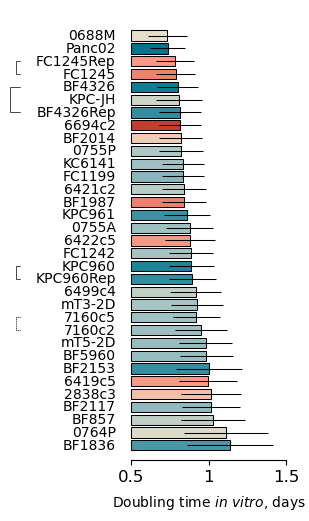

In [10]:
name = 'in_vitro_doubling_time'
si = 'si'

fig, ax = plt.subplots(figsize=(2, 6))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_position(('axes', 0.025))
ax_main.spines['bottom'].set_linewidth(0.5)

def doubling_time(N1, N2, f1, f2, dt): # in days
    r = (f2 * N2) / (f1 * N1)
    return dt * math.log(2) / math.log(r)
    
ys = []; errs = []
for clID in clIDs_ordered_in_vitro:
    ts = []
    t_minus_1 = 3 # starting from time point 1, not 0
    samples_minus_1 = in_vitro_samples[t_minus_1]
    for t, samples in in_vitro_samples.items():
        if t <= 3:
            continue
        dt = t - t_minus_1
        for rep in range(3):
            ts.append(doubling_time(metadata.loc[samples[rep]]['initial number of cells'], 
                                    metadata.loc[samples[rep]]['lung weight, g (in vivo) / cells (in vitro)'],
                                    read_counts_by_cell_line[samples_minus_1[rep]][clID] / sum(read_counts_by_cell_line[samples_minus_1[rep]][1:]),
                                    read_counts_by_cell_line[samples[rep]][clID] / sum(read_counts_by_cell_line[samples[rep]][1:]), 
                                    dt))
        t_minus_1 = t
        samples_minus_1 = samples

    ys.append(np.mean(ts) - 0.5); errs.append(np.std(ts))

cs = [clID__color_1[i] for i in clIDs_ordered_in_vitro]
clIDs_sorted_r = clIDs_ordered_in_vitro[::-1]

widths, lefts, xs, errs_for_bars, cs_for_bars = [], [], [], [[], []], []
c = 0
for clID in clIDs_sorted_r:
    xs.append(ys[::-1][c])
    errs_for_bars[0].append(errs[::-1][c])  
    errs_for_bars[1].append(errs[::-1][c])  
    cs_for_bars.append(clID__color_1[clID])
    
    lefts.append(0.5)  
    widths.append(xs[-1] - 0)  
    
    ax.text(0.4, c, clID__label[clID], va='center', ha='right', clip_on=False)
    c += 1

ax.barh(range(len(clIDs_sorted_r)), widths, height=0.8, left=lefts, color=cs_for_bars, 
        edgecolor='black', linewidth=0.75, clip_on=False)

ax.errorbar([x + 0.5 for x in xs], range(len(clIDs_sorted_r)), xerr=errs_for_bars, color='black', linewidth=0.75, 
            alpha=1, zorder=1, ls='none', clip_on=False)

ax.set_xscale('linear')  
ax.set_xlim(0.5, 1.5)
ax.set_xticks([0.5, 1.0, 1.5])
ax.set_xticklabels(['0.5', '1', '1.5'], size=12)

ax.set_yticks([])
ax.set_yticklabels([])

ax.set_xlabel('Doubling time ' + '$in$' + ' ' + '$vitro$' + ', days', fontsize=10, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    y = sorted([clIDs_ordered_in_vitro.index(key[0]) + 0.5, clIDs_ordered_in_vitro.index(key[1]) + 0.5])
    plt.annotate('', xy=(-0.2, len(clIDs_sorted_r) - y[0] - 0.5), xycoords='data', xytext=(-0.2, len(clIDs_sorted_r) - y[1] - 0.5), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.5'),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

### In vivo expansion

#### At 3 weeks of growth in immunocompetent mice:

In [11]:
# 3w F1 iv lung samples from exp. one (see bootstrapping.ipynb for details)

what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts
print(f'{len(samples)} mice in the group.')

clID__mean = utils.get_burden_and_n(samples)[0] # data mean
clID__err = {k: [max(0, clID__mean[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()} # bootstrapped confidence intervals

clIDs_sorted = [y[0] for y in sorted(clID__mean.items(), key=lambda x: x[-1], reverse=True)]

20 mice in the group.


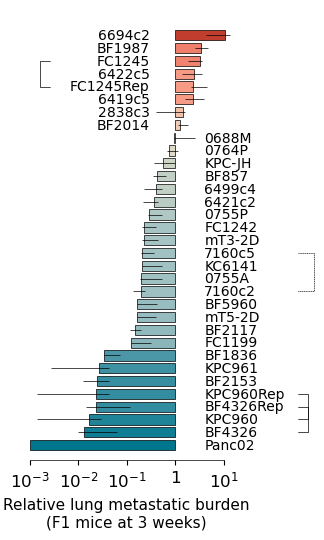

In [12]:
name = 'relative_in_vivo_expansion_3w_f1_exp1'
si = 'main'

fig, ax = plt.subplots(figsize=(2.5, 6))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_position(('axes', 0.025))
ax.spines['bottom'].set_linewidth(0.5)

clIDs_sorted_r = clIDs_sorted[::-1]
widths, lefts, xs, errs, cs = [], [], [], [[], []], []

c = 0
for i in clIDs_sorted_r:
    # parsing out bootstrapped data
    mean = clID__mean[i]
    err = clID__err[i]

    cs.append(clID__color_1[i])
    xs.append(max(1e-3, mean))
    errs[0].append(min(err[0], xs[-1] - 1e-3))
    errs[1].append(err[1])
        
    if mean > 1:
        lefts.append(1)
        widths.append(mean - 1)
        ax.text(0.3, c, clID__label[i], va='center', ha='right')
    else:
        lefts.append(max(1e-3, mean))
        widths.append(1 - mean)
        ax.text(4, c, clID__label[i], va='center', ha='left')
    c += 1

ax.barh(range(len(clIDs_sorted_r)), widths, height=0.8, left=lefts, color=cs, 
        edgecolor='black', linewidth=0.5, clip_on=False)
    
ax.errorbar(xs, range(len(clIDs_sorted_r)), xerr=errs, color='black', linewidth=0.5, 
            alpha=1, zorder=1, ls='none', clip_on=False)

ax.set_xscale('log')
ax.minorticks_off()
ax.set_xticks([1e-3, 1e-2, 1e-1, 1e0, 1e1])
ax.set_xticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^1$'], size=12)
ax.set_xlim(1e-3, 1e1)

ax.set_yticks([])
ax.set_yticklabels([])

ax.set_xlabel('Relative lung metastatic burden\n(F1 mice at 3 weeks)', fontsize=11, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    y = sorted([clIDs_sorted.index(key[0]) + 0.5, clIDs_sorted.index(key[1]) + 0.5])
    if y[1] < 8:
        x = 0.003
        s = 'bar,fraction=-0.5'
    else:
        x = 300
        s = 'bar,fraction=0.5'
    plt.annotate('', xy=(x, len(clIDs_sorted_r) - y[0] - 0.5), xycoords='data', xytext=(x, len(clIDs_sorted_r) - y[1] - 0.5), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle=s),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

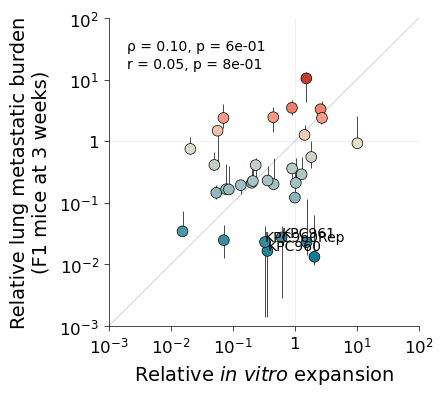

In [13]:
name = 'relative_in_vivo_vs_in_vitro_expansion_exp1'
si = 'main'

ax = utils.correlation_plot(clIDs_no_spikein,
                            clID__y=clID__mean, clID__yerr=clID__err,
                            clID__x=clID__in_vitro_exp, clID__xerr=clID__in_vitro_exp_err,
                            ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', xtitle='Relative ' + '$in$' + ' ' + '$vitro$' + ' expansion',
                            ylims=[1e-3, 1e2], xlims=[1e-3, 1e2])
                           
plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

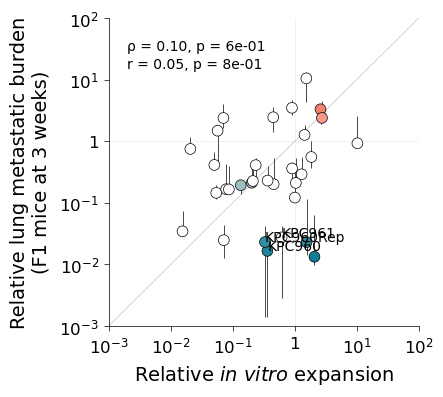

In [14]:
name = 'relative_in_vivo_vs_in_vitro_expansion_exp_1_reps'
si = 'si'

ax = utils.correlation_plot(clIDs_no_spikein,
                            clID__color = dict(zip(clIDs, [clID__color_1[x] if x in np.array(clIDs_rep).flatten() else 'white' for x in clIDs])),
                            clID__y=clID__mean, clID__yerr=clID__err,
                            clID__x=clID__in_vitro_exp, clID__xerr=clID__in_vitro_exp_err,
                            ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', xtitle='Relative ' + '$in$' + ' ' + '$vitro$' + ' expansion',
                            ylims=[1e-3, 1e2], xlims=[1e-3, 1e2])

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

#### At 2 days of growth in immunocompetent mice:

In [15]:
# 2d F1 iv lung samples from exp. one (see bootstrapping.ipynb for details)
what = ['1', 3, 'C57B6/129S F1', 'intravenous', 'lung']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] <= what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__mean_2d = utils.get_burden_and_n(samples, min_tumor_size=0)[0] # data mean
clID__err_2d = {k: [max(0, clID__mean_2d[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_2d[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()}

clIDs_sorted_2d = [y[0] for y in sorted(clID__mean_2d.items(), key=lambda x: x[-1], reverse=True)]

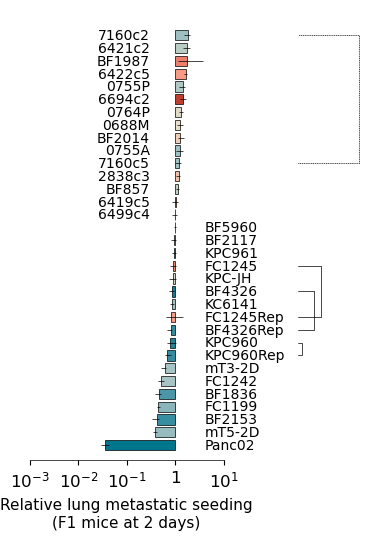

In [16]:
name = 'relative_in_vivo_expansion_2d_f1_exp1'
si = 'si'

fig, ax = plt.subplots(figsize=(2.5, 6))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_position(('axes', 0.025))
ax.spines['bottom'].set_linewidth(0.5)

clIDs_sorted_2d_r = clIDs_sorted_2d[::-1]
widths, lefts, xs, errs, cs = [], [], [], [[], []], []

c = 0
for i in clIDs_sorted_2d_r:
    # parsing out bootstrapped data
    mean = clID__mean_2d[i]
    err = clID__err_2d[i]

    cs.append(clID__color_1[i])
    xs.append(max(1e-3, mean))
    errs[0].append(min(err[0], xs[-1] - 1e-3))
    errs[1].append(err[1])
        
    if mean > 1:
        lefts.append(1)
        widths.append(mean - 1)
        ax.text(0.3, c, clID__label[i], va='center', ha='right')
    else:
        lefts.append(max(1e-3, mean))
        widths.append(1 - mean)
        ax.text(4, c, clID__label[i], va='center', ha='left')
    c += 1

ax.barh(range(len(clIDs_sorted_2d_r)), widths, height=0.8, left=lefts, color=cs, 
        edgecolor='black', linewidth=0.5, clip_on=False)
    
ax.errorbar(xs, range(len(clIDs_sorted_2d_r)), xerr=errs, color='black', linewidth=0.5, 
            alpha=1, zorder=1, ls='none', clip_on=False)

ax.set_xscale('log')
ax.minorticks_off()
ax.set_xticks([1e-3, 1e-2, 1e-1, 1e0, 1e1])
ax.set_xticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^1$'], size=12)
ax.set_xlim(1e-3, 1e1)

ax.set_yticks([])
ax.set_yticklabels([])

ax.set_xlabel('Relative lung metastatic seeding\n(F1 mice at 2 days)', fontsize=11, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    y = sorted([clIDs_sorted_2d.index(key[0]) + 0.5, clIDs_sorted_2d.index(key[1]) + 0.5])
    if y[1] < 8:
        x = 0.003
        s = 'bar,fraction=-0.5'
    else:
        x = 300
        s = 'bar,fraction=0.5'
    plt.annotate('', xy=(x, len(clIDs_sorted_2d_r) - y[0] - 0.5), xycoords='data', xytext=(x, len(clIDs_sorted_2d_r) - y[1] - 0.5), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle=s),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

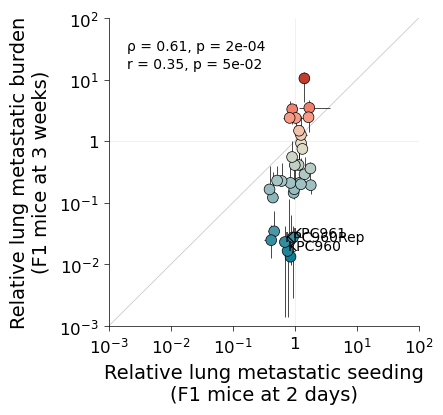

In [17]:
name = 'relative_in_vivo_expansion_vs_relative_seeding_exp1'
si = 'main'

ax = utils.correlation_plot(clIDs_no_spikein,
                            clID__y=clID__mean, clID__yerr=clID__err,
                            clID__x=clID__mean_2d, clID__xerr=clID__err_2d,
                            ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', xtitle='Relative lung metastatic seeding\n(F1 mice at 2 days)',
                            ylims=[1e-3, 1e2], xlims=[1e-3, 1e2])
                            
ax.spines[['top', 'right']].set_visible(False)

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

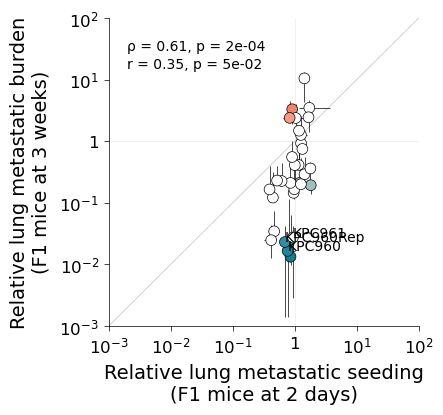

In [18]:
name = 'relative_in_vivo_expansion_vs_relative_seeding_exp_1_reps'
si = 'si'

ax = utils.correlation_plot(clIDs_no_spikein,
                            clID__color = dict(zip(clIDs, [clID__color_1[x] if x in np.array(clIDs_rep).flatten() else 'white' for x in clIDs])),
                            clID__y=clID__mean, clID__yerr=clID__err,
                            clID__x=clID__mean_2d, clID__xerr=clID__err_2d,
                            ytitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', xtitle='Relative lung metastatic seeding\n(F1 mice at 2 days)',
                            ylims=[1e-3, 1e2], xlims=[1e-3, 1e2])
                            
ax.spines[['top', 'right']].set_visible(False)

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

### Immune rejection

In [19]:
# 3w Rag1 iv lung samples from exp. one (see bootstrapping.ipynb for details)
what = ['1', 20, 'Rag1-/-', 'intravenous', 'lung']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__mean_rag1 = utils.get_burden_and_n(samples)[0] # data mean
clID__err_rag1 = {k: [max(0, clID__mean_rag1[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_rag1[k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()}

clIDs_sorted_rag1 = [y[0] for y in sorted(clID__mean_rag1.items(), key=lambda x: x[-1], reverse=True)]

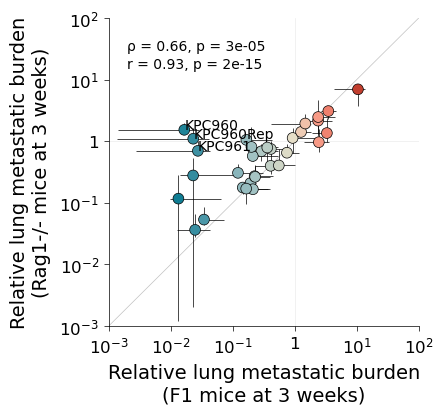

In [20]:
name = 'relative_in_vivo_expansion_w_and_wo_immune_system_exp1'
si = 'main'

ax = utils.correlation_plot(clIDs_no_spikein,
                            clID__x=clID__mean, clID__xerr=clID__err,
                            clID__y=clID__mean_rag1, clID__yerr=clID__err_rag1,
                            xtitle='Relative lung metastatic burden\n(F1 mice at 3 weeks)', ytitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks)',
                            ylims=[1e-3, 1e2], xlims=[1e-3, 1e2])
                            
ax.spines[['top', 'right']].set_visible(False)

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

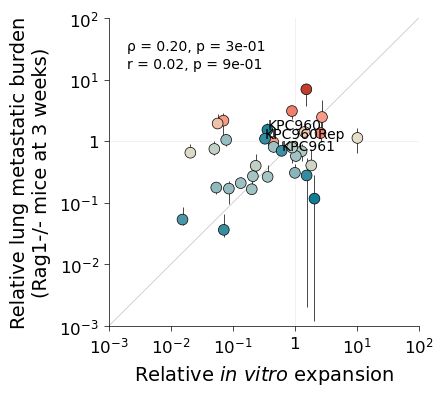

In [21]:
name = 'relative_in_vivo_expansion_wo_immune_system_vs_relative_in_vitro_expansion_exp1'
si = 'si'

ax = utils.correlation_plot(clIDs_no_spikein,
                            clID__x=clID__in_vitro_exp, clID__xerr=clID__in_vitro_exp_err,
                            clID__y=clID__mean_rag1, clID__yerr=clID__err_rag1,
                            xtitle='Relative ' + '$in$' + ' ' + '$vitro$' + ' expansion', ytitle='Relative lung metastatic burden\n(Rag1-/- mice at 3 weeks)',
                            ylims=[1e-3, 1e2], xlims=[1e-3, 1e2])

ax.spines[['top', 'right']].set_visible(False)

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

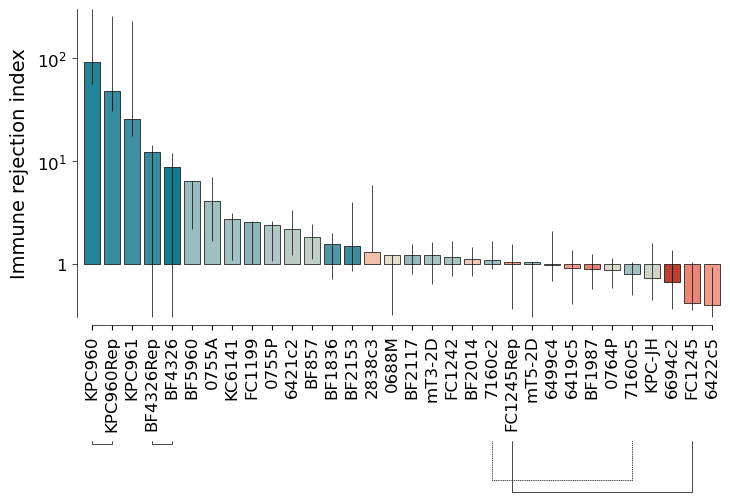

In [22]:
name = 'immune_rejection_index_exp1'
si = 'si'

# be careful w/ the tag below
index = utils.bootstrap_index(what__relative_burden_bootstraps['burden_bootstrap__' + tag.replace('Rag1--', 'C57B6129SF1')], 
                              what__relative_burden_bootstraps['burden_bootstrap__' + tag])
index.pop('AGCA') # not including Panc02

clID__mean_index = {k: clID__mean_rag1[k] / clID__mean[k] for k in index.keys()}
clID__err_index = {k: [max(0, clID__mean_index[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_index[k])] for k, v in index.items()}

clIDs_sorted_index = [y[0] for y in sorted(clID__mean_index.items(), key=lambda x: x[-1], reverse=True)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_position(('axes', -0.025))
ax.spines['left'].set_position(('axes', -0.025))

ax.spines[['bottom', 'left']].set_linewidth(0.5)
ax.yaxis.set_tick_params(width=0.5)

heights, bottoms, ys, errs, cs = [], [], [], [[], []], []

for i in clIDs_sorted_index:
    cs.append(clID__color_1[i])
    ys.append(clID__mean_index[i])
    errs[0].append(min(clID__err_index[i][0], ys[-1] - 3e-1)) # be careful here
    errs[1].append(min(clID__err_index[i][1], 0.3e3 - ys[0]))

    if clID__mean_index[i] > 1:
        bottoms.append(1)
        heights.append(clID__mean_index[i] - 1)
    else:
        bottoms.append(clID__mean_index[i])
        heights.append(1 - clID__mean_index[i])

ax.bar(range(len(clIDs_sorted_index)), heights, width=0.8, bottom=bottoms, color=cs,
       edgecolor='black', linewidth=0.5, clip_on=False)

ax.errorbar(range(len(clIDs_sorted_index)), ys, yerr=errs, color='black', linewidth=0.5,
            alpha=1, zorder=1, ls='none', clip_on=False)

ax.set_yscale('log')
ax.minorticks_off()
ax.set_yticks([1e-1, 1e0, 1e1, 1e2, 1e3])
ax.set_yticklabels(['$10^{-1}$', '$1$', '$10^{1}$', '$10^{2}$', '$10^{3}$'], size=12)
ax.set_ylim(3e-1, 0.3e3)

ax.set_xlim(0, len(clIDs_sorted_index) - 1)
ax.set_xticks(range(len(clIDs_sorted_index)))
ax.set_xticklabels([clID__label[x] for x in clIDs_sorted_index], size=12, rotation=90)

ax.set_ylabel('Immune rejection index', fontsize=14, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    y = 0.02
    x = sorted([clIDs_sorted_index.index(key[0]), clIDs_sorted_index.index(key[1])])
    ax.annotate('', xy=(x[0], y), xycoords='data', xytext=(x[1], y), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle=value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,angle=180,fraction=-0.3'),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

In [23]:
# 2d Rag1 iv lung samples from exp. one (see bootstrapping.ipynb for details)
what = ['1', 3, 'Rag1-/-', 'intravenous', 'lung']
tag = '_'.join([str(w).replace('/', '').replace(' ', '') for w in what])
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] <= what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

clID__mean_rag1_2d = utils.get_burden_and_n(samples, min_tumor_size=100)[0] # data mean
clID__err_rag1_2d = {k: [max(0, clID__mean_rag1_2d[k] - np.percentile(v, 2.5)), max(0, np.percentile(v, 97.5) - clID__mean_rag1_2d [k])] for k, v in what__relative_burden_bootstraps['burden_bootstrap__' + tag].items()}

clIDs_sorted_rag1_2d = [y[0] for y in sorted(clID__mean_rag1_2d.items(), key=lambda x: x[-1], reverse=True)]

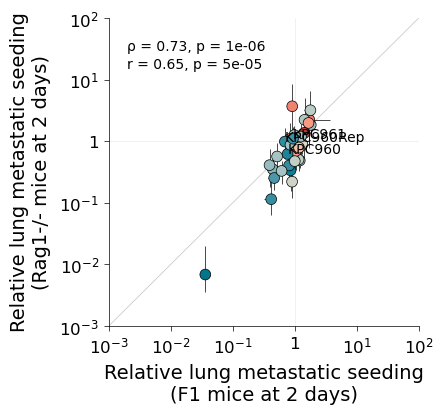

In [24]:
name = 'relative_in_vivo_expansion_w_and_wo_immune_system_2d_exp1'
si = 'si'

ax = utils.correlation_plot(clIDs_no_spikein,
                            clID__x=clID__mean_2d, clID__xerr=clID__err_2d,
                            clID__y=clID__mean_rag1_2d, clID__yerr=clID__err_rag1_2d,
                            xtitle='Relative lung metastatic seeding\n(F1 mice at 2 days)', ytitle='Relative lung metastatic seeding\n(Rag1-/- mice at 2 days)',
                            xlims=[1e-3, 1e2], ylims=[1e-3, 1e2])

ax.spines[['top', 'right']].set_visible(False)

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

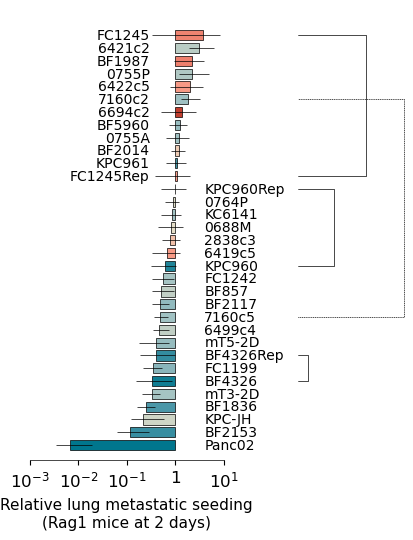

In [25]:
name = 'relative_in_vivo_expansion_2d_rag1_exp1'
si = 'si'

fig, ax = plt.subplots(figsize=(2.5, 6))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_position(('axes', 0.025))
ax.spines['bottom'].set_linewidth(0.5)

clIDs_sorted_rag1_2d_r = clIDs_sorted_rag1_2d[::-1]
widths, lefts, xs, errs, cs = [], [], [], [[], []], []

c = 0
for i in clIDs_sorted_rag1_2d_r:
    # parsing out bootstrapped data
    mean = clID__mean_rag1_2d[i]
    err = clID__err_rag1_2d[i]

    cs.append(clID__color_1[i])
    xs.append(max(1e-3, mean))
    errs[0].append(min(err[0], xs[-1] - 1e-3))
    errs[1].append(err[1])
        
    if mean > 1:
        lefts.append(1)
        widths.append(mean - 1)
        ax.text(0.3, c, clID__label[i], va='center', ha='right')
    else:
        lefts.append(max(1e-3, mean))
        widths.append(1 - mean)
        ax.text(4, c, clID__label[i], va='center', ha='left')
    c += 1

ax.barh(range(len(clIDs_sorted_2d_r)), widths, height=0.8, left=lefts, color=cs, 
        edgecolor='black', linewidth=0.5, clip_on=False)
    
ax.errorbar(xs, range(len(clIDs_sorted_2d_r)), xerr=errs, color='black', linewidth=0.5, 
            alpha=1, zorder=1, ls='none', clip_on=False)

ax.set_xscale('log')
ax.minorticks_off()
ax.set_xticks([1e-3, 1e-2, 1e-1, 1e0, 1e1])
ax.set_xticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^1$'], size=12)
ax.set_xlim(1e-3, 1e1)

ax.set_yticks([])
ax.set_yticklabels([])

ax.set_xlabel('Relative lung metastatic seeding\n(Rag1 mice at 2 days)', fontsize=11, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    y = sorted([clIDs_sorted_rag1_2d.index(key[0]) + 0.5, clIDs_sorted_rag1_2d.index(key[1]) + 0.5])
    if y[1] < 8:
        x = 0.003
        s = 'bar,fraction=-0.5'
    else:
        x = 300
        s = 'bar,fraction=0.5'
    plt.annotate('', xy=(x, len(clIDs_sorted_2d_r) - y[0] - 0.5), xycoords='data', xytext=(x, len(clIDs_sorted_rag1_2d_r) - y[1] - 0.5), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle=s),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

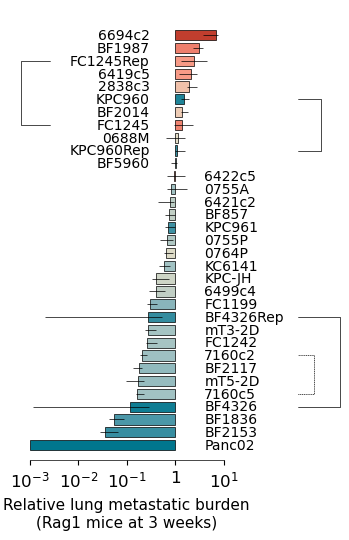

In [26]:
name = 'relative_in_vivo_expansion_3w_rag1_exp1'
si = 'si'

fig, ax = plt.subplots(figsize=(2.5, 6))
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_position(('axes', 0.025))
ax.spines['bottom'].set_linewidth(0.5)

clIDs_sorted_rag1_r = clIDs_sorted_rag1[::-1]
widths, lefts, xs, errs, cs = [], [], [], [[], []], []

c = 0
for i in clIDs_sorted_rag1_r:
    # parsing out bootstrapped data
    mean = clID__mean_rag1[i]
    err = clID__err_rag1[i]

    cs.append(clID__color_1[i])
    xs.append(max(1e-3, mean))
    errs[0].append(min(err[0], xs[-1] - 1e-3))
    errs[1].append(err[1])
        
    if mean > 1:
        lefts.append(1)
        widths.append(mean - 1)
        ax.text(0.3, c, clID__label[i], va='center', ha='right')
    else:
        lefts.append(max(1e-3, mean))
        widths.append(1 - mean)
        ax.text(4, c, clID__label[i], va='center', ha='left')
    c += 1

ax.barh(range(len(clIDs_sorted_rag1_r)), widths, height=0.8, left=lefts, color=cs, 
        edgecolor='black', linewidth=0.5, clip_on=False)
    
ax.errorbar(xs, range(len(clIDs_sorted_rag1_r)), xerr=errs, color='black', linewidth=0.5, 
            alpha=1, zorder=1, ls='none', clip_on=False)

ax.set_xscale('log')
ax.minorticks_off()
ax.set_xticks([1e-3, 1e-2, 1e-1, 1e0, 1e1])
ax.set_xticklabels(['$10^{-3}$', '$10^{-2}$', '$10^{-1}$', '$1$', '$10^1$'], size=12)
ax.set_xlim(1e-3, 1e1)

ax.set_yticks([])
ax.set_yticklabels([])

ax.set_xlabel('Relative lung metastatic burden\n(Rag1 mice at 3 weeks)', fontsize=11, labelpad=6)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    y = sorted([clIDs_sorted_rag1.index(key[0]) + 0.5, clIDs_sorted_rag1.index(key[1]) + 0.5])
    if y[1] < 8:
        x = 0.003
        s = 'bar,fraction=-0.5'
    else:
        x = 300
        s = 'bar,fraction=0.5'
    plt.annotate('', xy=(x, len(clIDs_sorted_rag1_r) - y[0] - 0.5), xycoords='data', xytext=(x, len(clIDs_sorted_rag1_r) - y[1] - 0.5), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle=s),
                annotation_clip=False);

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight') 

### Supplementary figure: read to cell number conversion

/var/folders/_s/rgzqgl4109s0w2jw2kc70qf40000gn/T/ipykernel_44695/1731226530.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(1 + np.random.normal(0, 0.012), sum(read_counts_by_cell_line[subsample][0] for subsample in metadata.loc[sample_id]['notes'].split()[0].split(':')) / 50000, color=c, zorder=z)
/var/folders/_s/rgzqgl4109s0w2jw2kc70qf40000gn/T/ipykernel_44695/1731226530.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(1 + np.random.normal(0, 0.012), sum(read_counts_by_cell_line[subsample][0] / 50000 for subsample in metadata.loc[sample_id]['notes'].split()[0].split(':')), color=c, 

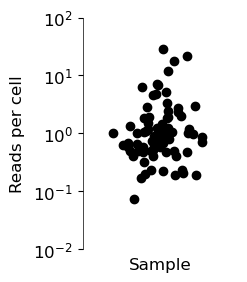

In [27]:
name = 'read_to_cell_number_conversion_exp1'
si = 'si'

fig, ax = plt.subplots(figsize=(2, 3))
ax.spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines['left'].set_linewidth(0.5)

processed_samples = []; used_labels = []
np.random.seed(0) 
for sample_id in metadata.index:
    if sample_id in processed_samples:
        continue
    if metadata.loc[sample_id]['spike-in added'] == False:
        continue
    if metadata.loc[sample_id]['experiment'] != '1':
        continue

    c = 'black'; z=1
        
    if metadata.loc[sample_id]['notes'] == 'none': # no need to merge anything
        plt.scatter(1 + np.random.normal(0, 0.012), read_counts_by_cell_line.loc['GATC'][sample_id] / 50000, color=c, zorder=z)    
    elif 'one' in metadata.loc[sample_id]['notes']:
        plt.scatter(1 + np.random.normal(0, 0.012), sum(read_counts_by_cell_line[subsample][0] for subsample in metadata.loc[sample_id]['notes'].split()[0].split(':')) / 50000, color=c, zorder=z)
        processed_samples.extend([subsample for subsample in metadata.loc[sample_id]['notes'].split()[0].split(':')])
    else: 
        plt.scatter(1 + np.random.normal(0, 0.012), sum(read_counts_by_cell_line[subsample][0] / 50000 for subsample in metadata.loc[sample_id]['notes'].split()[0].split(':')), color=c, zorder=z)
        processed_samples.extend([subsample for subsample in metadata.loc[sample_id]['notes'].split()[0].split(':')])
        
plt.yscale('log')
plt.minorticks_off()
plt.xlim(0.95, 1.05)
plt.ylim(1e-2, 1e2)
plt.xticks([], []);
plt.yticks(size=12)

plt.ylabel('Reads per cell', fontsize=12, labelpad=6);
plt.xlabel('Sample', fontsize=12, labelpad=6);

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

### Supplementary figure: number of unique barcodes recovered from the first experiment

5970
20


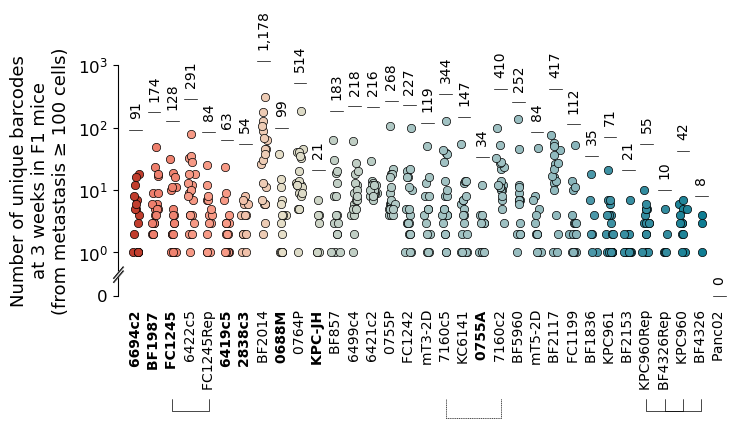

In [28]:
name = 'n_unique_barcodes_3w_f1_exp1'
si = 'si'

plt.figure(figsize=(8, 3))
plt.gca().spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines['left'].set_linewidth(0.5)

n = 0

# making a list of 3w F1 iv lung samples from exp. one
what = ['1', 20, 'C57B6/129S F1', 'intravenous', 'lung']
samples = list(set(metadata.loc[(metadata['experiment'] == what[0]) & 
                                (metadata['time point, d'] > what[1]) & # be careful here
                                (metadata['genotype'] == what[2]) &
                                (metadata['injection method'] == what[3]) & 
                                (metadata['tissue'] == what[4])
].apply(lambda row: row['notes'].split()[0] if row['notes'] != 'none' else row.name, axis=1).tolist())) # choosing the correct name for merged counts

# getting tumor sizes:
mouse_clID_barcode_size = utils.convert_barcode_reads_to_cell_counts(samples)

# count unique barcodes per clID per mouse
n_tumors = mouse_clID_barcode_size[mouse_clID_barcode_size['size'] >= 100].groupby(['mouse', 'clID'])['barcode'].nunique().reset_index(name='n_barcodes')

clID__n_tumors = {clID: [] for clID in clIDs_no_spikein}
for clID in clIDs[1:]:
    values = n_tumors[n_tumors['clID'] == clID]['n_barcodes'].tolist()
    clID__n_tumors[clID].extend(values)

for i, clID in enumerate(clIDs_sorted):
    plt.scatter(i + np.random.normal(0, 0.1, len(clID__n_tumors[clID])), [0.2 if x == 0 else x for x in clID__n_tumors[clID]], 
                color=clID__color_1[clID], edgecolor='black', linewidth=0.5, clip_on=False)
    
    
    if sum(clID__n_tumors[clID]) > 0:
        plt.plot([i - 0.35, i + 0.35], [sum(clID__n_tumors[clID]), sum(clID__n_tumors[clID])], color='black', linewidth=0.5, clip_on=False)
        if sum(clID__n_tumors[clID]) >= 1e3:
            plt.text(i, 1.5 * sum(clID__n_tumors[clID]), str(sum(clID__n_tumors[clID]))[0] + ',' + str(sum(clID__n_tumors[clID]))[1:], va='bottom', ha='center', rotation=90)
        else:
            plt.text(i, 1.5 * sum(clID__n_tumors[clID]), str(sum(clID__n_tumors[clID])), va='bottom', ha='center', rotation=90)
        
        n += sum(clID__n_tumors[clID])
        
    else:
        plt.plot([i - 0.35, i + 0.35], [0.2, 0.2], color='black', linewidth=0.5, clip_on=False, zorder=1)
        plt.text(i, 1.5 * 0.2, str(sum(clID__n_tumors[clID])), va='bottom', ha='center', rotation=90)

plt.yscale('log')
plt.minorticks_off()

plt.ylim(2e-1, 1e3)
plt.xlim(-1, i + 1)
    
# make sure that the order is correct
plt.xticks(range(len(clIDs_sorted)), []);
plt.gca().set_xticklabels([clID__label[x] + '  ' for x in clIDs_sorted], size=10, rotation=90)
plt.gca().xaxis.set_tick_params(length=0, width=0, which='both')
plt.yticks([2e-1, 1e0, 1e1, 1e2, 1e3], ['0', '$10^{0}$', '$10^{1}$', '$10^{2}$', '$10^{3}$'], size=12)

clID__weight = {}
for clID in clIDs:
    if clID__label[clID] in ['6694c2', '6419c5', 'BF1987', '0688M', 'FC1245', 'FC1245', 'KPC-JH', '0755A', '2838c3']:
        clID__weight[clID] = 'bold'
    else:
        clID__weight[clID] = 'normal'
        
for label, clID in zip(plt.gca().get_xticklabels(), clIDs_sorted):
    label.set_fontproperties(matplotlib.font_manager.FontProperties(weight=clID__weight[clID]))  

for i in np.logspace(np.log10(0.35), np.log10(0.4), 10):
    plt.text(-1.4, i, '|', rotation=-40, size=12, color='white')
plt.text(-1.4, 0.35, '|', rotation=-40, size=12)
plt.text(-1.4, 0.4, '|', rotation=-40, size=12)

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = sorted([clIDs_sorted.index(key[0]), clIDs_sorted.index(key[1])])
    plt.annotate('', xy=(x[0], 0.005), xycoords='data', xytext=(x[1], 0.005), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.4'),
                annotation_clip=False);

plt.ylabel('Number of unique barcodes\nat 3 weeks in F1 mice\n(from metastasis ≥ 100 cells)', fontsize=13, labelpad=6);

print(n)
print(len(samples))

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    

### Supplementary figure: cell line proportions in the pre-injection pool

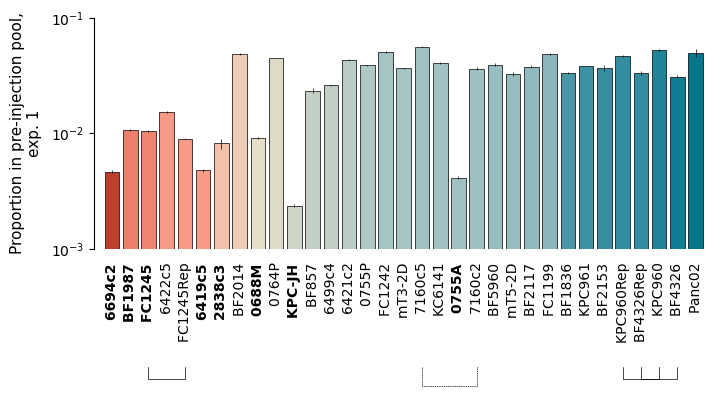

In [30]:
# pre-injection sample
clID__sample__reads = {}
for sample in list(metadata[(metadata['time point, d'] == 0) & (metadata['experiment'] == '1')].index):
    clID__sample__reads[sample] = {}
    file_path = os.path.join(path_to_reads, f"{sample}_clIDs_rBC_cluster_counts.txt")
    
    with open(file_path, 'r') as f:
        for line in f:
            clID_barcode, read_count = line.strip().split('\t')
            clID, barcode = clID_barcode.split('_'); read_count = int(read_count)
            if clID not in clIDs: # this should not happen if barcodes were processed correctly
                continue
            if clID not in clID__sample__reads[sample]:
                clID__sample__reads[sample][clID] = []
            clID__sample__reads[sample][clID].append(read_count) # adding read counts!


name = 'initial_cell_line_proportions_exp1'
si = 'si'

plt.figure(figsize=(8, 3))
plt.gca().spines[['top', 'right', 'bottom']].set_visible(False)
ax.spines['left'].set_linewidth(0.5)

# all samples
samples = list(clID__sample__reads.keys())
# all reads per sample
norms = {s: sum(sum(clID__sample__reads[s][clID]) for clID in clIDs_sorted) for s in samples}

# compute mean and std across samples
clID__mean_frac = {}
clID__std_frac = {}

for clID in clIDs_sorted:
    vals = []
    for s in samples:
        vals.append(sum(clID__sample__reads[s][clID]) / norms[s])
    clID__mean_frac[clID] = np.mean(vals)
    clID__std_frac[clID] = np.std(vals)
    
for i, clID in enumerate(clIDs_sorted):
    y = clID__mean_frac[clID]
    plt.bar(i, y - 1e-3, bottom=1e-3, color=clID__color_1[clID], edgecolor='black', linewidth=0.5)
    plt.errorbar(i, y, yerr=clID__std_frac[clID], color='black', linewidth=0.5, ls='none', zorder=3)

plt.yscale('log')
plt.minorticks_off()

plt.ylim(1e-3, 1e-1)
plt.xlim(-1, i + 1)
    
# make sure that the order is correct
plt.xticks(range(len(clIDs_sorted)), []);
plt.gca().set_xticklabels([clID__label[x] + '  ' for x in clIDs_sorted], size=10, rotation=90)
plt.gca().xaxis.set_tick_params(length=0, width=0, which='both')

clID__weight = {}
for clID in clIDs:
    if clID__label[clID] in ['6694c2', '6419c5', 'BF1987', '0688M', 'FC1245', 'FC1245', 'KPC-JH', '0755A', '2838c3']:
        clID__weight[clID] = 'bold'
    else:
        clID__weight[clID] = 'normal'
        
for label, clID in zip(plt.gca().get_xticklabels(), clIDs_sorted):
    label.set_fontproperties(matplotlib.font_manager.FontProperties(weight=clID__weight[clID]))  

# connecting replicate cell lines by lines
for key, value in clID_replicates__linestyle.items():
    x = sorted([clIDs_sorted.index(key[0]), clIDs_sorted.index(key[1])])
    plt.annotate('', xy=(x[0], 0.0001), xycoords='data', xytext=(x[1], 0.0001), textcoords='data',
                arrowprops=dict(arrowstyle='-', linestyle = value, linewidth=0.5, color='0',
                patchA=None, patchB=None, connectionstyle='bar,fraction=-0.4'),
                annotation_clip=False);

plt.ylabel('Proportion in pre-injection pool,\nexp. 1', fontsize=11, labelpad=6);
# print(tmp)

plt.savefig(path_to_save_figs + 'fig2/figs/' + si + '_' + name + '.pdf', dpi=300, bbox_inches='tight')    